<h1>3.6 DSSD multiplicity：从条的组合到粒子候选</h1><p>本节沿着“两面幅度和 → multiplicity 相关 offset → 相邻条 → 候选配对”的顺序，判断一片 DSSD 中有几个粒子、位置在哪里、每个粒子分配多少能量。</p><p><code>data/cal_16C.root</code> 保存逐条的相对刻度结果。以 DSSD1 为例：</p><pre><code class="language-cpp">Int_t x1hit, y1hit;       // 超过阈值的条数
Int_t x1[32], y1[32];     // 条号；有效长度由 x1hit/y1hit 给出
Double_t x1e[32], y1e[32];// 相对幅度，还不是 MeV
Double_t x1es, y1es;     // 两面相对幅度和
Int_t x1m, y1m;           // 相邻条的连通组数</code></pre><p><code>xhit</code> 不等于粒子数；<code>xm</code> 也只是空间连通组数。两个相邻 hit 可能来自一个粒子的 sharing，也可能来自两个相邻粒子，不能先无条件合并再当成答案。</p>

In [ ]:
TFile *ipf = new TFile("./data/cal_16C.root");
TTree *tree = (TTree*)ipf->Get("tree");

<h2>1. 两面总幅度的一致性</h2>

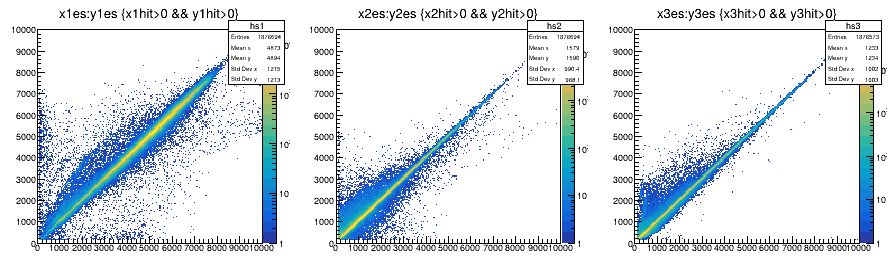

In [4]:
TCanvas *c1 = new TCanvas("c1","c1",900,300);
c1->Divide(3,1);
c1->cd(1);
tree->Draw("x1es:y1es>>hs1(200,0,10000,200,0,10000)","x1hit>0 && y1hit>0","colz");
gPad->SetLogz();
c1->cd(2);
tree->Draw("x2es:y2es>>hs2(200,0,10000,200,0,10000)","x2hit>0 && y2hit>0","colz");
gPad->SetLogz();
c1->cd(3);
tree->Draw("x3es:y3es>>hs3(200,0,10000,200,0,10000)","x3hit>0 && y3hit>0","colz");
gPad->SetLogz();
c1->Draw();

<h3>条的 multiplicity</h3><p>先比较 X、Y 两面有效条数。两面 hit 数不同不一定意味着数据无效。</p>

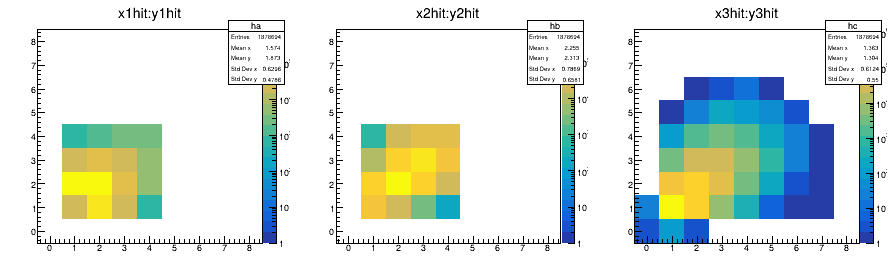

In [6]:
c1->Clear();
c1->Divide(3,1);
c1->cd(1);
gPad->SetLogz();
tree->Draw("x1hit:y1hit>>ha(9,-0.5,8.5,9,-0.5,8.5)","","colz");
c1->cd(2);
gPad->SetLogz();
tree->Draw("x2hit:y2hit>>hb(9,-0.5,8.5,9,-0.5,8.5)","","colz");
c1->cd(3);
gPad->SetLogz();
tree->Draw("x3hit:y3hit>>hc(9,-0.5,8.5,9,-0.5,8.5)","","colz");
c1->Draw();

<h3>两面幅度和的差</h3><p>差值不总在零附近，而出现相隔近似固定幅度的结构。接着查看它与两面 hit 数之差的关系。</p>

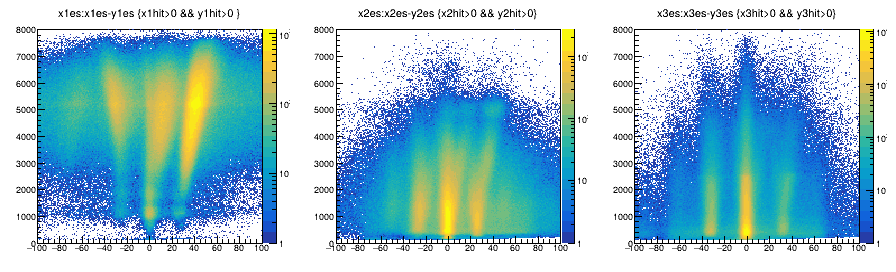

In [8]:
TCut cdet1 ="x1hit>0 && y1hit>0 ";
TCut cdet2 ="x2hit>0 && y2hit>0";
TCut cdet3 ="x3hit>0 && y3hit>0";
c1->Clear();
gStyle->SetOptStat(0);
c1->Divide(3,1);
c1->cd(1);
tree->Draw("x1es:x1es-y1es>>hds1(200,-100,100,200,0,8000)",cdet1,"colz");
gPad->SetLogz();
c1->cd(2);
tree->Draw("x2es:x2es-y2es>>hds2(200,-100,100,200,0,8000)",cdet2,"colz");
gPad->SetLogz();
c1->cd(3);
tree->Draw("x3es:x3es-y3es>>hds3(200,-100,100,200,0,8000)",cdet3,"colz");
gPad->SetLogz();
c1->Draw();

<h3>幅度和之差与 multiplicity 之差</h3><p>观察不同 hit 数差对应的中心位置，检查是否可由共同 offset 描述。</p>

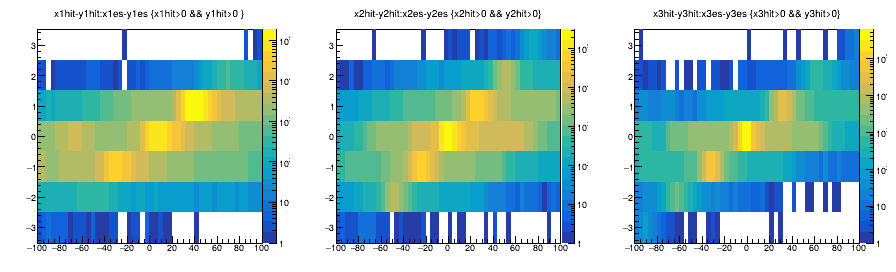

In [10]:
c1->Clear();
gStyle->SetOptStat(0);
c1->Divide(3,1);
c1->cd(1);
tree->Draw("x1hit-y1hit:x1es-y1es>>h2ds1(50,-100,100,7,-3.5,3.5)",cdet1 ,"colz");
gPad->SetLogz();
c1->cd(2);
tree->Draw("x2hit-y2hit:x2es-y2es>>h2ds2(50,-100,100,7,-3.5,3.5)",cdet2,"colz");
gPad->SetLogz();
c1->cd(3);
tree->Draw("x3hit-y3hit:x3es-y3es>>h2ds3(50,-100,100,7,-3.5,3.5)",cdet3,"colz");
gPad->SetLogz();
c1->Draw();

<h3>共同 offset 为什么要逐条修正？</h3>
<p>设相对归一后的单条幅度为 $A_i'$，绝对能量还需共同变换 $E_i=kA_i'+b$。若两面有效条数为 $m_x,m_y$，
$$xes=\sum_{i=1}^{m_x}A'_{x_i},\qquad yes=\sum_{j=1}^{m_y}A'_{y_j},$$
则两面能量和为
$$E_x=k\,xes+m_xb,\qquad E_y=k\,yes+m_yb.$$
对于电荷收集完整的事例 $E_x=E_y$，因此
$$xes-yes=(m_y-m_x)\frac{b}{k}.$$</p>
<p>上图的斜率给出共同 offset 的线索。本参考刻度采用 $b/k=-25,-25,-30$，分别对应 DSSD1、2、3。把每条幅度加上 $b/k$ 后再求和，避免两面条数不同产生人为偏移。这些数值属于本参考刻度；重新求相对刻度后需重新检查。</p>

In [ ]:
tree->SetAlias("x1esc","x1es+x1hit*(-25)");
tree->SetAlias("y1esc","y1es+y1hit*(-25)");
tree->SetAlias("x2esc","x2es+x2hit*(-25)");
tree->SetAlias("y2esc","y2es+y2hit*(-25)");
tree->SetAlias("x3esc","x3es+x3hit*(-30)");
tree->SetAlias("y3esc","y3es+y3hit*(-30)");

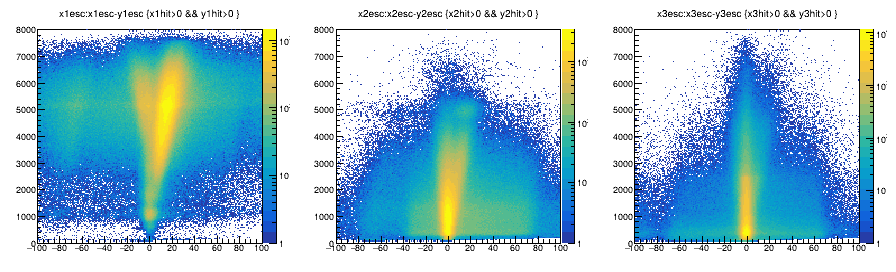

In [13]:
c1->Clear();
gStyle->SetOptStat(0);
c1->Divide(3,1);
c1->cd(1);
TCut cdet1 ="x1hit>0 && y1hit>0 ";
tree->Draw("x1esc:x1esc-y1esc>>hds1(200,-100,100,200,0,8000)",cdet1,"colz");
gPad->SetLogz();
c1->cd(2);
TCut cdet2 ="x2hit>0 && y2hit>0 ";
tree->Draw("x2esc:x2esc-y2esc>>hds2(200,-100,100,200,0,8000)",cdet2,"colz");
gPad->SetLogz();
c1->cd(3);
TCut cdet3 ="x3hit>0 && y3hit>0 ";
tree->Draw("x3esc:x3esc-y3esc>>hds3(200,-100,100,200,0,8000)",cdet3,"colz");
gPad->SetLogz();
c1->Draw();

<h3>相邻条信号与剩余趋势</h3>
<p>共同 offset 修正后仍有随幅度变化的 residual。邻条耦合、阈值以下未记录的共享电荷及收集不完整，都可能造成这种趋势；仅凭幅度和不能区分这些机制。</p>
<p>原图展示几类相邻条关联：A 区有 sharing 条带，B、C 区为一强一弱的相关信号，D 区在 pedestal 附近。右图放大弱信号区域，显示弱信号可随主信号增加。若弱信号低于读出阈值，相应电荷与 hit 数就不在记录中。</p><img alt="Adjacent Strip Correlation" src="fig/x1x2_correlation.png"/><p>当前谱中约 40/6000≈0.67% 的残余偏移，在总能量上不大，但对要求数个幅度单位精度的配对仍可能重要。下面的 gate 保留了这项实验特征；不通过修改事件幅度把它“拉直”。</p>

<h3>两面总能量 gate</h3><p>在 $xesc$ 对 $(xesc-yesc)$ 的图上，沿主条带选择候选。文件 <code>cutd1esc.cut</code> 等保存的是本参考数据使用的多边形。这个 gate 检查<strong>全事件的能量和</strong>，并未决定单个粒子的 x-y 对应。</p>

In [ ]:
gROOT->Macro("cutd1esc.cut");
gROOT->Macro("cutd2esc.cut");
gROOT->Macro("cutd3esc.cut");

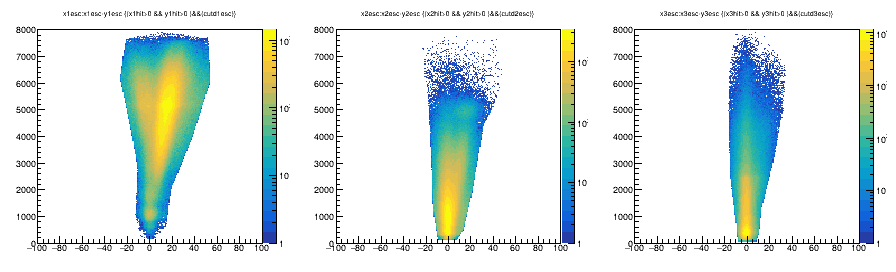

In [17]:
c1->Clear();
gStyle->SetOptStat(0);
c1->Divide(3,1);
c1->cd(1);
TCut cdet1 ="x1hit>0 && y1hit>0 ";
tree->Draw("x1esc:x1esc-y1esc>>hds1(200,-100,100,200,0,8000)",cdet1 && "cutd1esc","colz");
gPad->SetLogz();
c1->cd(2);
TCut cdet2 ="x2hit>0 && y2hit>0 ";
tree->Draw("x2esc:x2esc-y2esc>>hds2(200,-100,100,200,0,8000)",cdet2 && "cutd2esc","colz");
gPad->SetLogz();
c1->cd(3);
TCut cdet3 ="x3hit>0 && y3hit>0 ";
tree->Draw("x3esc:x3esc-y3esc>>hds3(200,-100,100,200,0,8000)",cdet3 && "cutd3esc","colz");
gPad->SetLogz();
c1->Draw();

<h2>2. 把每种分类当成待检验的假设</h2>
<p>下面保留原有拓扑图，但读图时先说清：哪些 hit 归为一个粒子，哪些两面信号互相配对。条号检查相邻关系；能量关系检验候选。这里的 <code>x1ec0</code> 指第 0 个 X hit 修正后的幅度，并不指第 0 条。</p>
<table><thead><tr><th>候选</th><th>检验量</th><th>需要比较的替代假设</th></tr></thead><tbody>
<tr><td>X、Y 各两条，各自对应一个粒子</td><td>$r_1=X_0-Y_0,\ r_2=X_1-Y_1$</td><td>交换 Y：$X_0-Y_1,\ X_1-Y_0$</td></tr>
<tr><td>X 两条，Y 三条中的 a、b 共享</td><td>$r_1=X_i-(Y_a+Y_b),\ r_2=X_{1-i}-Y_c$</td><td>枚举相邻的 a、b，并对 i=0、1 都检验</td></tr>
<tr><td>两面各三条，三粒子</td><td>三个 $X_i-Y_{\pi(i)}$</td><td>三条 Y 的全部 6 个排列</td></tr>
</tbody></table>
<p><strong>斜条带本身不是正确配对的证据。</strong>前面已经限制两面能量和，所以两粒子的 $r_1+r_2\approx0$；错误配对也可落在负斜率线上。需要两个 residual 同时接近零，并检查是否还有其他候选也通过。共享条求和后，组的能量顺序可能变化，不能继续假定原先按单条能量排序的下标就是配对顺序。</p>
<p>以下图分别展示若干候选的 residual，而不是自动完成分类。稍后用一个完整的两条对三条实例，把这种检验写成可执行的判断。</p>

In [ ]:
int off[3] = {25, 25, 30};

// Define energy-corrected (ec) aliases for the first 3 hits in DSSD 1, 2, and 3
for(int id=1; id<=3; id++){
    for(int i=0; i<3; i++){
        tree->SetAlias(Form("x%dec%d", id, i), Form("x%de[%d]-%d", id, i, off[id-1]));
        tree->SetAlias(Form("y%dec%d", id, i), Form("y%de[%d]-%d", id, i, off[id-1]));    
    }
}

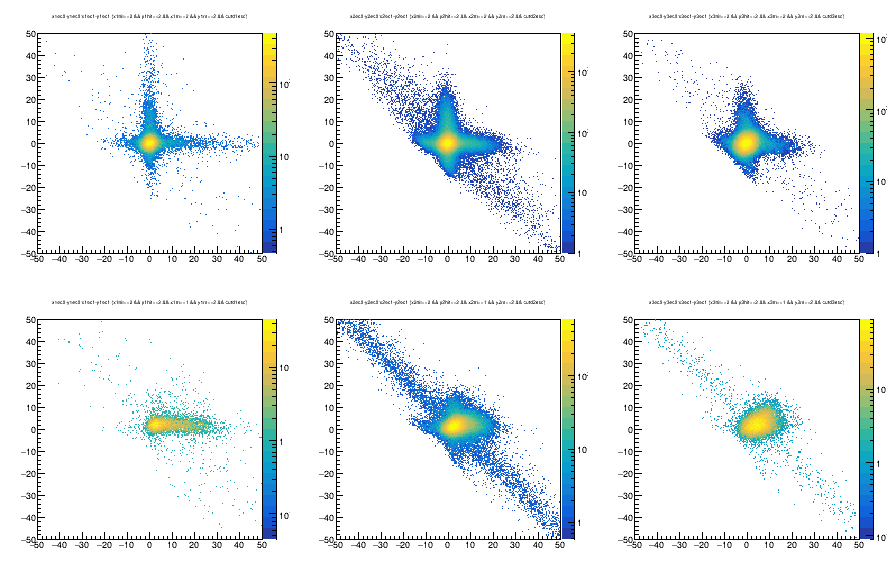

In [20]:
TCut cut ;
TCanvas *c2 = new TCanvas("c2","c2",900,600);
c2->Clear();
c2->Divide(3,2);
/* 
   x: 0 1 |   01  |  0  1  |  01 |
   y: 0 1 |  0  1 |   01   |  01 |
       ——                         
*/
for(int i=1; i<=3; i++) {
    cut = Form("x%dhit==2 && y%dhit==2 && x%dm==2 && y%dm==2 && cutd%desc",i,i,i,i,i);
    c2->cd(i);
    TString sdraw = Form("x%dec0-y%dec0:x%dec1-y%dec1>>h%da(200,-50,50,200,-50,50)",i,i,i,i,i);
    tree->Draw(sdraw,cut,"colz");
    gPad->SetLogz();
}
/* 
   x: 0 1 |   01  |  0  1  |  01 |
   y: 0 1 |  0  1 |   01   |  01 |
               ——                         
*/
for(int i=1; i<=3; i++) {
    cut = Form("x%dhit==2 && y%dhit==2 && x%dm==1 && y%dm==2 && cutd%desc",i,i,i,i,i);
    c2->cd(i+3);
    TString sdraw = Form("x%dec0-y%dec0:x%dec1-y%dec1>>h%db(200,-50,50,200,-50,50)",i,i,i,i,i);
    tree->Draw(sdraw,cut,"colz");
    gPad->SetLogz();
}

c2->Draw();

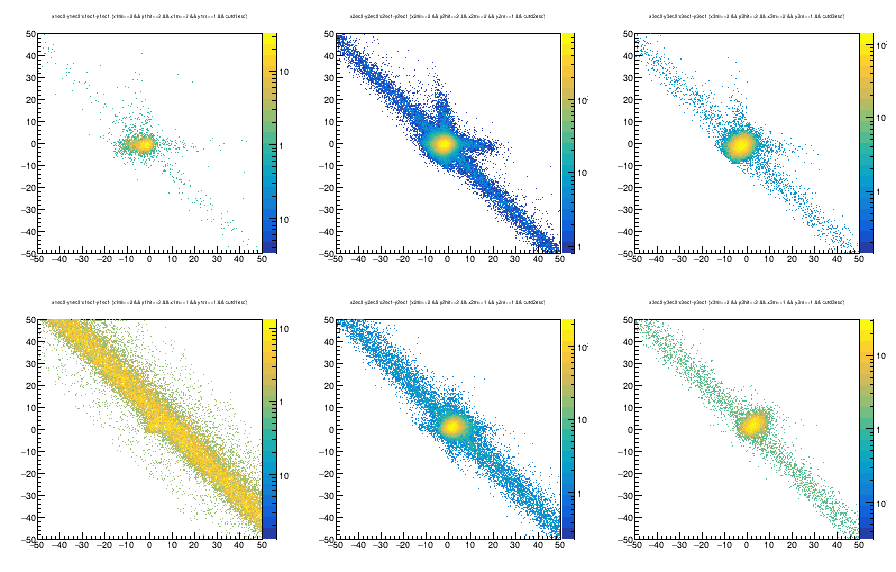

In [21]:
TCut cut ;
c2->Clear();
c2->Divide(3,2);
/* 
   x: 0 1 |   01  |  0  1  |  01 |
   y: 0 1 |  0  1 |   01   |  01 |
                      ——                         
*/
for(int i=1; i<=3; i++) {
    cut = Form("x%dhit==2 && y%dhit==2 && x%dm==2 && y%dm==1 && cutd%desc",i,i,i,i,i);
    c2->cd(i);
    TString sdraw = Form("x%dec0-y%dec0:x%dec1-y%dec1>>h%dc(200,-50,50,200,-50,50)",i,i,i,i,i);
    tree->Draw(sdraw,cut,"colz");
    gPad->SetLogz();
}
/* 
   x: 0 1 |   01  |  0  1  |  01 |
   y: 0 1 |  0  1 |   01   |  01 |
                              ——                         
*/
for(int i=1; i<=3; i++) {
    cut = Form("x%dhit==2 && y%dhit==2 && x%dm==1 && y%dm==1 && cutd%desc",i,i,i,i,i);
    c2->cd(i+3);
    TString sdraw = Form("x%dec0-y%dec0:x%dec1-y%dec1>>h%dd(200,-50,50,200,-50,50)",i,i,i,i,i);
    tree->Draw(sdraw,cut,"colz");
    gPad->SetLogz();
}
c2->Draw();

<h3>X 两条、Y 三条：尝试 Y 侧的 sharing 组</h3><p>三个面板组分别尝试 (0,1)、(1,2)、(0,2)。括号里是 hit 下标；对应条号相邻才允许求和。图中只显示一种对应，实际判断还要交换两个 X 候选。</p>

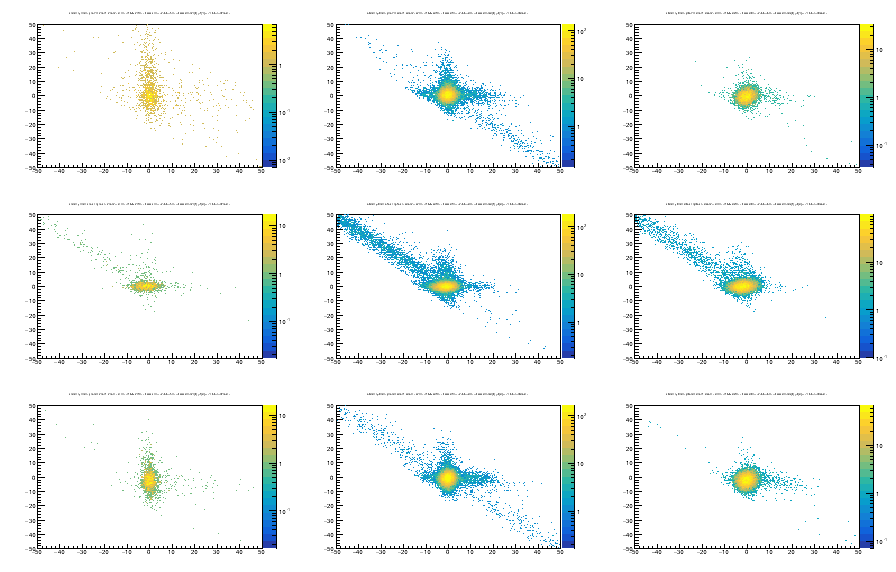

In [23]:
TCut cut ;
c2->Clear();
c2->Divide(3,3);
/*
x:   0  1 |   0  1  |  0  1 | 01  2 |  0 12  | 02  1  |
y:  01  2 |   0  12 | 02  1 |  0  1 |  0  1  |  0  1  |
      ——
*/

for(int i=1; i<=3; i++) {
    cut = Form("x%dhit==2 && y%dhit==3 && x%dm==2 && y%dm==2 && abs(y%d[0]-y%d[1])==1 && cutd%desc",i,i,i,i,i,i,i);
    c2->cd(i);
    gPad->SetLogz();
    tree->Draw(Form("x%dec0-(y%dec0+y%dec1):x%dec1-y%dec2>>h%da(200,-50,50,200,-50,50)",i,i,i,i,i,i),cut,"colz");;
}
/*
x:   0  1 |   0  1  |  0  1 | 01  2 |  0 12  | 02  1  |
y:  01  2 |   0  12 | 02  1 |  0  1 |  0  1  |  0  1  |
               ——
*/
for(int i=1; i<=3; i++) {
    cut = Form("x%dhit==2 && y%dhit==3 && x%dm==2 && y%dm==2 && abs(y%d[1]-y%d[2])==1 && cutd%desc",i,i,i,i,i,i,i);
    c2->cd(i+3);
    gPad->SetLogz();
    tree->Draw(Form("x%dec0-y%dec0:x%dec1-(y%dec1+y%dec2)>>h%db(200,-50,50,200,-50,50)",i,i,i,i,i,i),cut,"colz");;
}
/*
x:   0  1 |   0  1  |  0  1 | 01  2 |  0 12  | 02  1  |
y:  01  2 |   0  12 | 02  1 |  0  1 |  0  1  |  0  1  |
                        ——
*/
for(int i=1; i<=3; i++) {
    cut = Form("x%dhit==2 && y%dhit==3 && x%dm==2 && y%dm==2 && abs(y%d[0]-y%d[2])==1 && cutd%desc",i,i,i,i,i,i,i);
    c2->cd(i+6);
    gPad->SetLogz();
    tree->Draw(Form("x%dec0-(y%dec0+y%dec2):x%dec1-y%dec1>>h%dc(200,-50,50,200,-50,50)",i,i,i,i,i,i),cut,"colz");;
}

c2->Draw();

<h3>X 三条、Y 两条</h3><p>与上一种情况对称，在 X 面枚举相邻组，并比较两种与 Y 的对应关系。</p>

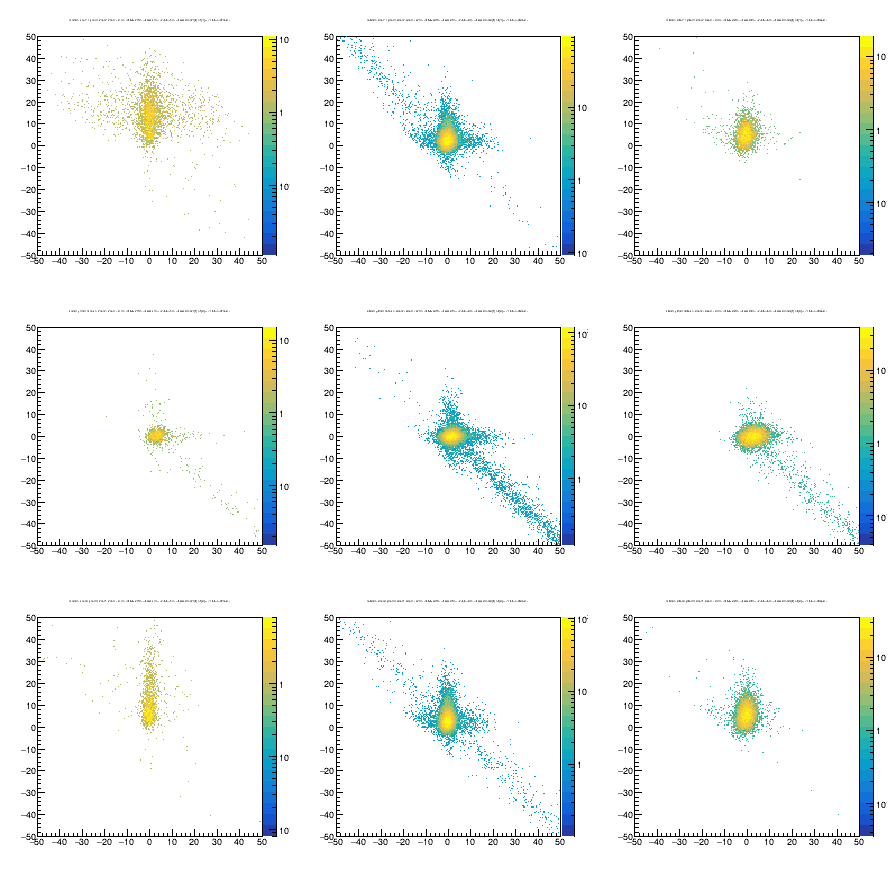

In [25]:
TCut cut ;
TCanvas *c3 = new TCanvas("c3","c3",900,900);
c3->Clear();
c3->Divide(3,3);
/*
x:   0  1 |   0  1  |  0  1 | 01  2 |  0 12  | 02  1  |
y:  01  2 |   0  12 | 02  1 |  0  1 |  0  1  |  0  1  |
                                ——
*/
for(int i=1; i<=3; i++) {
    cut = Form("x%dhit==3 && y%dhit==2 && x%dm==2 && y%dm==2 && abs(x%d[0]-x%d[1])==1 && cutd%desc",i,i,i,i,i,i,i);
    c3->cd(i);
    gPad->SetLogz();
    tree->Draw(Form("(x%dec0+x%dec1)-y%dec0:x%dec2-y%dec1>>h%de(200,-50,50,200,-50,50)",i,i,i,i,i,i),cut,"colz");;
}
/*
x:   0  1 |   0  1  |  0  1 | 01  2 |  0 12  | 02  1  |
y:  01  2 |   0  12 | 02  1 |  0  1 |  0  1  |  0  1  |
                                        ——
*/
for(int i=1; i<=3; i++) {
    cut = Form("x%dhit==3 && y%dhit==2 && x%dm==2 && y%dm==2 && abs(x%d[1]-x%d[2])==1 && cutd%desc",i,i,i,i,i,i,i);
    c3->cd(i+3);
    gPad->SetLogz();
    tree->Draw(Form("x%dec0-y%dec0:(x%dec1+x%dec2)-y%dec1>>h%df(200,-50,50,200,-50,50)",i,i,i,i,i,i),cut,"colz");;
}
/*
x:   0  1 |   0  1  |  0  1 | 01  2 |  0 12  | 02  1  |
y:  01  2 |   0  12 | 02  1 |  0  1 |  0  1  |  0  1  |
                                                 ——
*/
for(int i=1; i<=3; i++) {
    cut = Form("x%dhit==3 && y%dhit==2 && x%dm==2 && y%dm==2 && abs(x%d[0]-x%d[2])==1 && cutd%desc",i,i,i,i,i,i,i);
    c3->cd(i+6);
    gPad->SetLogz();
    tree->Draw(Form("(x%dec0+x%dec2-y%dec0):x%dec1-y%dec1>>h%dg(200,-50,50,200,-50,50)",i,i,i,i,i,i),cut,"colz");;
}
c3->Draw();

<h3>两面各三条</h3><p>先显示按当前能量顺序直接配对的三个 residual 之间的关系。三粒子判断要检验三项，同时比较 6 种排列；只看其中一对接近零还不够。</p>

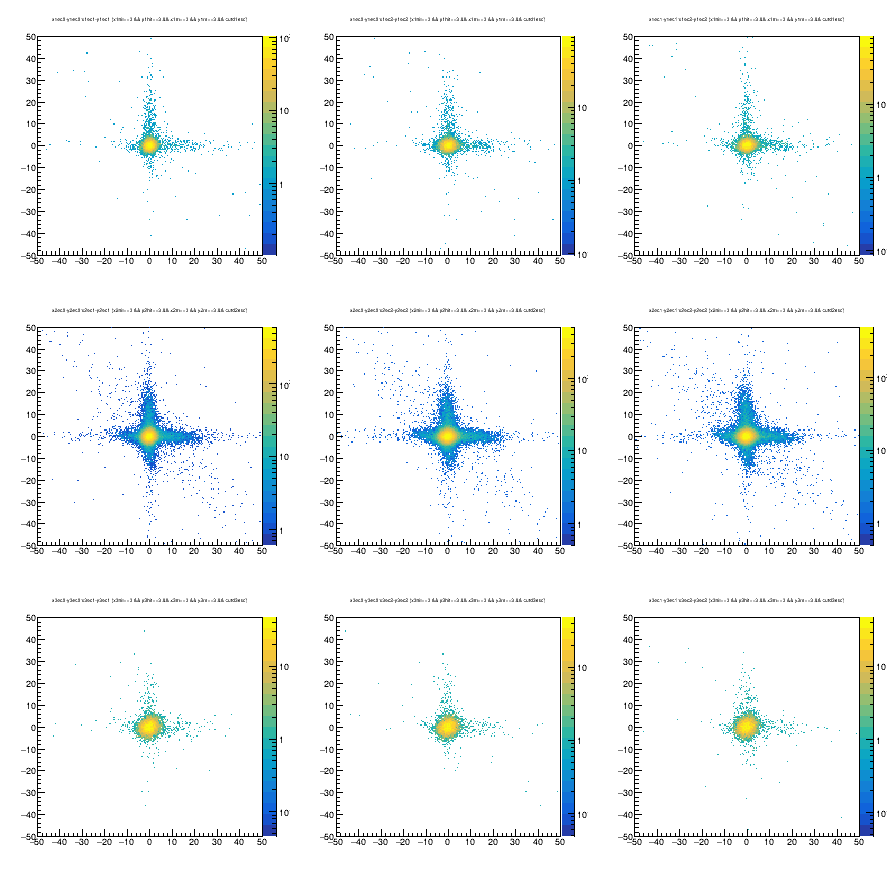

In [27]:
TCut cut ;
c3->Clear();
c3->Divide(3,3);
for(int i=1; i<=3; i++) {
    cut = Form("x%dhit==3 && y%dhit==3 && x%dm==3 && y%dm==3 && cutd%desc",i,i,i,i,i);
    c3->cd(3*i-2);
    gPad->SetLogz();
    tree->Draw(Form("x%dec0-y%dec0:x%dec1-y%dec1>>h%da(200,-50,50,200,-50,50)",i,i,i,i,i),cut ,"colz");
    c3->cd(3*i-1);
    gPad->SetLogz();
    tree->Draw(Form("x%dec0-y%dec0:x%dec2-y%dec2>>h%db(200,-50,50,200,-50,50)",i,i,i,i,i),cut ,"colz");
    c3->cd(3*i);
    gPad->SetLogz();
    tree->Draw(Form("x%dec1-y%dec1:x%dec2-y%dec2>>h%dc(200,-50,50,200,-50,50)",i,i,i,i,i),cut ,"colz");
}
c3->Draw();

<h2>3. 可运行实例：X 两条、Y 三条</h2>
<p>选择 DSSD2 中两条 X 互不相邻、Y 恰有一个相邻双条组的事例，检验“两粒子，其中一个在 Y 面 sharing”的模型。不先加总能量 gate，以便看见全部几何候选的 residual。</p>
<p>对每个相邻组，计算 <code>rGroup</code> 和 <code>rSingle</code>，并尝试 X 的两种对应。下面的函数返回通过条件的候选数。一次求和包含几条，就逐条扣几次共同 offset，不能只给整个组扣一次。</p>

<pre><code class="language-cpp">inline int Pair23(const int x[2], const int y[3],
                  const double ex[2], const double ey[3], double tolerance,
                  int&amp; groupA, int&amp; groupB, int&amp; single, int&amp; matchedX) {
    if (std::abs(x[0]-x[1])&lt;=1) return 0;
    int count=0;
    for (int a=0; a&lt;3; ++a) {
        for (int b=a+1; b&lt;3; ++b) {
            int c=3-a-b; // 剩下的 Y hit，下标为 0+1+2-a-b
            if (std::abs(y[a]-y[b])!=1) continue;
            if (std::abs(y[c]-y[a])&lt;=1 || std::abs(y[c]-y[b])&lt;=1) continue;
            for (int i=0; i&lt;2; ++i) { // 合并的 Y 组分别尝试对应 X[0]、X[1]
                double rGroup=ex[i]-(ey[a]+ey[b]);
                double rSingle=ex[1-i]-ey[c];
                if (std::abs(rGroup)&gt;tolerance || std::abs(rSingle)&gt;tolerance) continue;
                ++count;
                groupA=a; groupB=b; single=c; matchedX=i;
            }
        }
    }
    return count;
}</code></pre><p><code>tolerance</code> 是两个 residual 各自允许的绝对差。下面以相对幅度 15 为演示值，结合候选分布检查；它不是已标定的 3σ，也不是所有幅度和 multiplicity 都通用的宽度。精细分析可由干净样本确定随幅度与共享条数变化的匹配宽度。</p>

<h3>输入、状态与输出</h3><p>完整事件循环见 <a href="reconstruct_two_particles.C">reconstruct_two_particles.C</a>，配对函数见 <a href="dssd_pairing.h">dssd_pairing.h</a>。输入为 <code>data/cal_16C.root</code>，输出另存为 <code>two_particle_candidates.root</code>。</p>
<ul><li><code>nCandidates=1</code>：在本两粒子模型中唯一，记录两个粒子的条号、幅度和 residual。</li><li><code>nCandidates=0</code> 或大于 1：保留无解或多解状态，<code>hit=0</code> 表示本例未给出确定重建，不表示物理上没有粒子。</li></ul>
<p>X 面两个分开的 hit 提供两个粒子的幅度；Y 共享组暂以较大幅度条定位，并保存其成员 <code>ymask</code>，不声称取得了亚条位置分辨。这里只检验一种两粒子拓扑，三粒子共条等替代模型仍由后面的作业讨论。</p>

In [31]:
gROOT->ProcessLine(".L reconstruct_two_particles.C");
gROOT->ProcessLine("reconstruct_two_particles(15);");
TFile *fCandidates=new TFile("two_particle_candidates.root");
TTree *candidateTree=fCandidates->Get<TTree>("tree");
candidateTree->Scan("source_entry:nCandidates:hit:x:y:e:residual","hit==2","",3);

Example input entry 40: Y[0]+Y[2] -> X[0], Y[1] -> X[1]
Input=1878694, (2,3)=190461, tested topology=97549
Tolerance=15, unique=68663, ambiguous=1253, no match=27633
Saved rows=97549
***********************************************************************************************************
*    Row   * Instance * source_en * nCandidat *       hit *         x *         y *         e *  residual *
***********************************************************************************************************
*        0 *        0 *        40 *         1 *         2 *         2 *        19 * 1928.2107 * 10.836302 *
*        0 *        1 *        40 *         1 *         2 *        12 *        13 * 464.27441 * 1.1699172 *
*        1 *        0 *        58 *         1 *         2 *        17 *         0 * 384.79693 * -3.146499 *
*        1 *        1 *        58 *         1 *         2 *        20 *        13 * 741.18670 * 0.4998214 *
*        2 *        0 *        68 *         1 *         2 *  

<h3>候选分布与通过选择的唯一解</h3><p>左图每个几何假设贡献一个点，右图每个唯一通过的事例贡献一个点。右图集中在零附近是筛选条件的结果，不是独立证明；需要同时看左图及打印的无解、多解计数。</p>

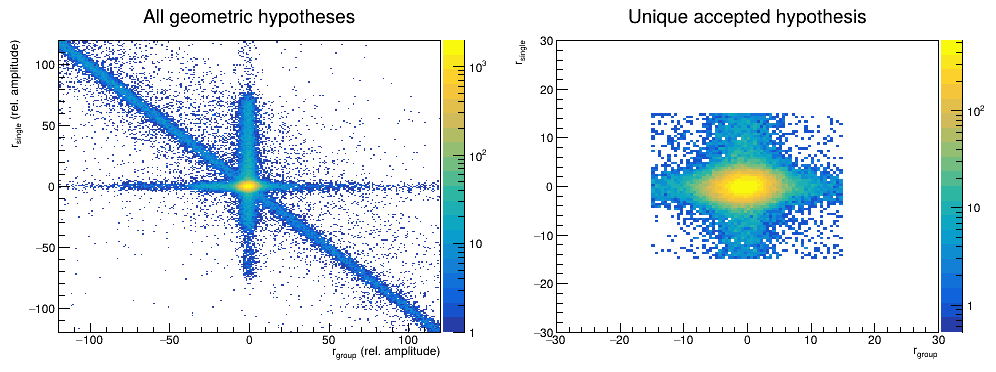

In [33]:
TCanvas *cCandidates=new TCanvas("cCandidates","Two-by-three reconstruction",1000,400);
cCandidates->Divide(2,1);
cCandidates->cd(1);
fCandidates->Get<TH2>("hCandidates")->Draw("colz"); gPad->SetLogz();
cCandidates->cd(2);
fCandidates->Get<TH2>("hUnique")->Draw("colz"); gPad->SetLogz();
cCandidates->Draw();

<h2 id="assignment">作业</h2>
<p>把上面的候选检验推广到两面各三条的事例：分别考虑三粒子的不同排列，以及一侧或两侧发生 sharing 的两粒子假设。参照原有 residual 图，比较哪些候选能同时满足各粒子的能量关系，再统计唯一解、多解和无解。</p>
<p>对于 X 两条、Y 三条的三粒子假设，还需考虑两粒子共用一条 X。此时 $X_{\rm shared}\approx Y_a+Y_b$，两个粒子的幅度可取来自能分辨它们的 Y 面；不能把完整的 $X_{\rm shared}$ 分别赋给两粒子，否则能量重复计数。</p>
<p>在新 ROOT 文件中保存每层的粒子候选 <code>hit,e[hit],x[hit],y[hit]</code>、重建类别、候选数和原事例编号。不要求仅凭本节信息给所有拓扑强行唯一解；保存未解决的状态，后续可引入层间位置关系检验。原始和参考文件保留不变。</p>